# Data Description – Football Match Dataset

In diesem Notebook werden die Daten des Datensatzes analysiert und für die spätere Verwendung in einem Machine-Learning-Modell vorbereitet.

## 2.1 Zielvariable

In diesem Projekt soll das Feld **FTResult** vorhergesagt werden.

Dieses Feld beschreibt das Endresultat eines Fussballspiels:

H – Heimsieg  
D – Unentschieden  
A – Auswärtssieg

Das Ziel ist es, anhand verschiedener Eigenschaften der Teams wie Elo-Rating, Form der letzten Spiele und Spielstatistiken vorherzusagen, welches Team ein Spiel gewinnt.

In [1]:
import pandas as pd

df = pd.read_csv("MatchesClean.csv", sep=";")
df.head()

C:\Users\faruk\AppData\Local\Temp\ipykernel_15036\4037602508.py:3: DtypeWarning: Columns (0: MatchTime) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("MatchesClean.csv", sep=";")


,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
0,F1,28.07.2000,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F1,28.07.2000,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F2,28.07.2000,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F1,29.07.2000,NaN,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F1,29.07.2000,NaN,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df.columns

Index(['Division', 'MatchDate', 'MatchTime', 'HomeTeam', 'AwayTeam', 'HomeElo',
       'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 'FTHome',
       'FTAway', 'FTResult', 'HTHome', 'HTAway', 'HTResult', 'HomeShots',
       'AwayShots', 'HomeTarget', 'AwayTarget', 'HomeFouls', 'AwayFouls',
       'HomeCorners', 'AwayCorners', 'HomeYellow', 'AwayYellow', 'HomeRed',
       'AwayRed', 'OddHome', 'OddDraw', 'OddAway', 'MaxHome', 'MaxDraw',
       'MaxAway', 'Over25', 'Under25', 'MaxOver25', 'MaxUnder25', 'HandiSize',
       'HandiHome', 'HandiAway', 'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD', 'C_HTB',
       'C_PHB'],
      dtype='str')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 230557 entries, 0 to 230556
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     230557 non-null  str    
 1   MatchDate    230557 non-null  str    
 2   MatchTime    99072 non-null   str    
 3   HomeTeam     230557 non-null  str    
 4   AwayTeam     230557 non-null  str    
 5   HomeElo      141597 non-null  float64
 6   AwayElo      141528 non-null  float64
 7   Form3Home    229057 non-null  float64
 8   Form5Home    229057 non-null  float64
 9   Form3Away    229057 non-null  float64
 10  Form5Away    229057 non-null  float64
 11  FTHome       230554 non-null  float64
 12  FTAway       230554 non-null  float64
 13  FTResult     230554 non-null  str    
 14  HTHome       175977 non-null  float64
 15  HTAway       175977 non-null  float64
 16  HTResult     175977 non-null  str    
 17  HomeShots    114735 non-null  float64
 18  AwayShots    114738 non-null  float

## 2.2 Statistische Analyse

Um die Daten besser zu verstehen, werden statistische Kennzahlen der numerischen Felder berechnet. Dazu gehören unter anderem der Median sowie die Standardabweichung. Diese Werte helfen dabei, die Verteilung der Daten und mögliche Unterschiede zwischen den Variablen zu erkennen.

In [4]:
df.describe()

,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,FTHome,FTAway,HTHome,HTAway,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
count,141597.000000,141528.000000,229057.000000,229057.000000,229057.000000,229057.000000,230554.000000,230554.000000,175977.000000,175977.000000,...,148397.000000,156733.000000,156475.000000,156451.000000,112602.000000,112602.000000,112602.000000,112602.000000,112602.000000,112602.000000
mean,1533.118663,1533.165652,3.984628,6.721606,4.203482,6.928241,1.488411,1.150646,0.657626,0.502782,...,1.986764,-0.303375,1.919722,1.954644,0.216225,0.200979,0.146727,0.126160,0.173664,0.136246
std,153.279601,153.294511,2.377010,3.257166,2.393202,3.269548,1.258901,1.112735,0.812627,0.715419,...,0.719088,0.729464,0.495534,0.351741,0.242283,0.239103,0.230572,0.216921,0.214677,0.199302
min,1103.130000,1103.130000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.260000,-99.900000,0.000000,-0.500000,0.009700,0.009700,0.009800,0.009700,0.009800,0.009700
25%,1424.870000,1424.930000,2.000000,4.000000,3.000000,4.000000,1.000000,0.000000,0.000000,0.000000,...,1.750000,-0.500000,1.830000,1.830000,0.036000,0.032000,0.011400,0.010000,0.031100,0.021400
50%,1515.450000,1515.475000,4.000000,7.000000,4.000000,7.000000,1.000000,1.000000,0.000000,0.000000,...,1.910000,-0.300000,1.920000,1.930000,0.102700,0.086300,0.036100,0.027100,0.073500,0.046800
75%,1634.240000,1634.222500,6.000000,9.000000,6.000000,9.000000,2.000000,2.000000,1.000000,1.000000,...,2.120000,0.000000,2.010000,2.020000,0.325100,0.286100,0.154900,0.112600,0.225300,0.147000
max,2107.480000,2107.480000,9.000000,15.000000,9.000000,15.000000,10.000000,13.000000,7.000000,7.000000,...,238.000000,12.500000,177.000000,15.140000,0.943700,0.944900,0.951200,0.951100,0.946500,0.941500


In [5]:
df.median(numeric_only=True)

HomeElo        1515.4500
AwayElo        1515.4750
Form3Home         4.0000
Form5Home         7.0000
Form3Away         4.0000
Form5Away         7.0000
FTHome            1.0000
FTAway            1.0000
HTHome            0.0000
HTAway            0.0000
HomeShots        12.0000
AwayShots        10.0000
HomeTarget        5.0000
AwayTarget        4.0000
HomeFouls        12.0000
AwayFouls        13.0000
HomeCorners       5.0000
AwayCorners       4.0000
HomeYellow        2.0000
AwayYellow        2.0000
HomeRed           0.0000
AwayRed           0.0000
OddHome           2.1500
OddDraw           3.4000
OddAway           3.3300
MaxHome           2.3000
MaxDraw           3.6000
MaxAway           3.5900
Over25            1.9400
Under25           1.8200
MaxOver25         2.0400
MaxUnder25        1.9100
HandiSize        -0.3000
HandiHome         1.9200
HandiAway         1.9300
C_LTH             0.1027
C_LTA             0.0863
C_VHD             0.0361
C_VAD             0.0271
C_HTB             0.0735


In [6]:
df.std(numeric_only=True)

HomeElo        153.279601
AwayElo        153.294511
Form3Home        2.377010
Form5Home        3.257166
Form3Away        2.393202
Form5Away        3.269548
FTHome           1.258901
FTAway           1.112735
HTHome           0.812627
HTAway           0.715419
HomeShots        4.999903
AwayShots        4.461799
HomeTarget       2.761119
AwayTarget       2.427446
HomeFouls        4.468416
AwayFouls        4.540744
HomeCorners      2.940007
AwayCorners      2.623002
HomeYellow       1.307300
AwayYellow       1.374269
HomeRed          0.297656
AwayRed          0.346100
OddHome          1.373112
OddDraw          0.849323
OddAway          2.647317
MaxHome          1.800707
MaxDraw          1.101367
MaxAway          3.812976
Over25           0.277402
Under25          0.335539
MaxOver25        0.538211
MaxUnder25       0.719088
HandiSize        0.729464
HandiHome        0.495534
HandiAway        0.351741
C_LTH            0.242283
C_LTA            0.239103
C_VHD            0.230572
C_VAD       

In [7]:
df.isnull().sum()

Division            0
MatchDate           0
MatchTime      131485
HomeTeam            0
AwayTeam            0
HomeElo         88960
AwayElo         89029
Form3Home        1500
Form5Home        1500
Form3Away        1500
Form5Away        1500
FTHome              3
FTAway              3
FTResult            3
HTHome          54580
HTAway          54580
HTResult        54580
HomeShots      115822
AwayShots      115819
HomeTarget     116628
AwayTarget     116625
HomeFouls      116584
AwayFouls      116584
HomeCorners    116194
AwayCorners    116194
HomeYellow     111259
AwayYellow     111258
HomeRed        111258
AwayRed        111260
OddHome          3030
OddDraw          3030
OddAway          3030
MaxHome         27635
MaxDraw         27635
MaxAway         27635
Over25          82159
Under25         82160
MaxOver25       82159
MaxUnder25      82160
HandiSize       73824
HandiHome       74082
HandiAway       74106
C_LTH          117955
C_LTA          117955
C_VHD          117955
C_VAD     

## 2.3 Datenvisualisierung

Zur besseren Analyse der Daten wird ein Histogramm erstellt. Dieses zeigt die Verteilung der Elo-Ratings der Heimteams. Dadurch kann man erkennen, wie stark die Teams im Datensatz im Durchschnitt sind und wie die Werte verteilt sind.

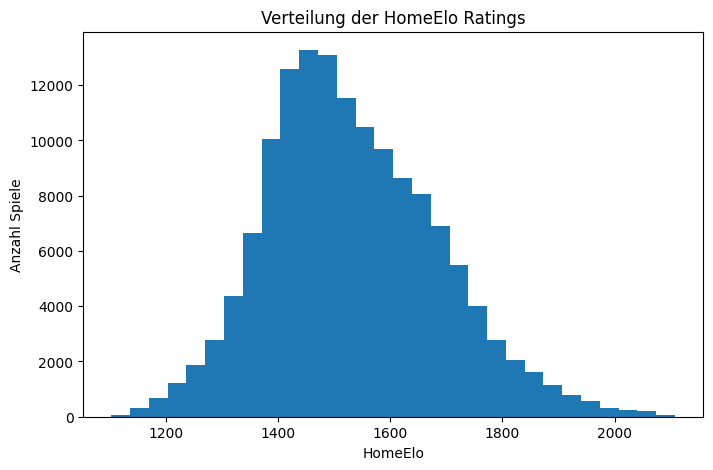

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["HomeElo"], bins=30)
plt.title("Verteilung der HomeElo Ratings")
plt.xlabel("HomeElo")
plt.ylabel("Anzahl Spiele")
plt.show()

## 2.4 Skalierung

Für Machine-Learning-Modelle ist es häufig sinnvoll, numerische Werte zu skalieren. Einige Algorithmen reagieren empfindlich auf unterschiedliche Wertebereiche.

In diesem Datensatz wurde das Feld **HomeElo** skaliert. Durch die Standardisierung werden die Werte so transformiert, dass sie einen Mittelwert von 0 und eine Standardabweichung von 1 haben. Dadurch werden die Daten vergleichbarer und das Modell kann effizienter trainiert werden. Die Skalierung wurde mit dem StandardScaler aus der sklearn-Bibliothek durchgeführt.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["HomeElo_scaled"] = scaler.fit_transform(df[["HomeElo"]])
df[["HomeElo", "HomeElo_scaled"]].head()

,HomeElo,HomeElo_scaled
0,1686.34,0.999623
1,1714.89,1.185885
2,1465.08,-0.443888
3,1635.58,0.668463
4,1734.34,1.312778
